In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [40]:
df = pd.read_csv('C:\\Users\\User\\OneDrive\\Desktop\\Python-master\\Python-master\\Smartphone_Usage.csv')
print(df.head(4))

  User_ID  Age  Gender      Occupation Device_Type  Daily_Phone_Hours  \
0      U1   58    Male    Professional     Android                1.3   
1      U2   25    Male    Professional     Android                1.2   
2      U3   19    Male         Student         iOS                5.3   
3      U4   35  Female  Business Owner         iOS                5.8   

   Social_Media_Hours  Work_Productivity_Score  Sleep_Hours  Stress_Level  \
0                 6.7                        6          8.8             4   
1                 1.5                        5          6.4             1   
2                 5.7                        5          9.0             4   
3                 2.5                        2          5.7             3   

   App_Usage_Count  Caffeine_Intake_Cups  Weekend_Screen_Time_Hours  
0               42                     1                        8.7  
1               51                     3                        5.1  
2               14                    

In [41]:
df.shape

(50000, 13)

In [42]:
df.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [43]:
#Find outlier values in Daily_Phone_Hours column
Q1 = df['Daily_Phone_Hours'].quantile(0.25)
Q3 = df['Daily_Phone_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_fense = Q1 - 1.5 * IQR
upper_fense = Q3 + 1.5 * IQR
outliers = df[(df['Daily_Phone_Hours'] < lower_fense) | (df['Daily_Phone_Hours'] > upper_fense)]
print(outliers)

Empty DataFrame
Columns: [User_ID, Age, Gender, Occupation, Device_Type, Daily_Phone_Hours, Social_Media_Hours, Work_Productivity_Score, Sleep_Hours, Stress_Level, App_Usage_Count, Caffeine_Intake_Cups, Weekend_Screen_Time_Hours]
Index: []


In [44]:
#Find outliers value in Age column
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
LF = Q1 - 1.5 * IQR
UF = Q3 + 1.5 * IQR
outliers = df[(df['Age'] < LF) | (df['Age'] > UF)]
print(outliers)

Empty DataFrame
Columns: [User_ID, Age, Gender, Occupation, Device_Type, Daily_Phone_Hours, Social_Media_Hours, Work_Productivity_Score, Sleep_Hours, Stress_Level, App_Usage_Count, Caffeine_Intake_Cups, Weekend_Screen_Time_Hours]
Index: []


In [45]:
#Find the outliers value in Sleep_Hours column
Q1 = df['Sleep_Hours'].quantile(0.25)
Q3 = df['Sleep_Hours'].quantile(0.75)
IQR = Q3 - Q1
LF = Q1 - 1.5 * IQR
UF = Q3 + 1.5 * IQR
outliers = df[(df['Sleep_Hours'] < LF) | (df['Sleep_Hours'] > UF)]
print(outliers)

Empty DataFrame
Columns: [User_ID, Age, Gender, Occupation, Device_Type, Daily_Phone_Hours, Social_Media_Hours, Work_Productivity_Score, Sleep_Hours, Stress_Level, App_Usage_Count, Caffeine_Intake_Cups, Weekend_Screen_Time_Hours]
Index: []


In [46]:
#Find outliers in Weekend_Screen_Time_Hours column
Q1 = df['Weekend_Screen_Time_Hours'].quantile(0.25)   
Q3 = df['Weekend_Screen_Time_Hours'].quantile(0.75)
IQR = Q3 - Q1
LF = Q1 - 1.5 * IQR
UF = Q3 + 1.5 * IQR
outliers = df[(df['Weekend_Screen_Time_Hours'] < LF) | (df['Weekend_Screen_Time_Hours'] > UF)]
print(outliers)

Empty DataFrame
Columns: [User_ID, Age, Gender, Occupation, Device_Type, Daily_Phone_Hours, Social_Media_Hours, Work_Productivity_Score, Sleep_Hours, Stress_Level, App_Usage_Count, Caffeine_Intake_Cups, Weekend_Screen_Time_Hours]
Index: []


<Axes: xlabel='Daily_Phone_Hours', ylabel='Count'>

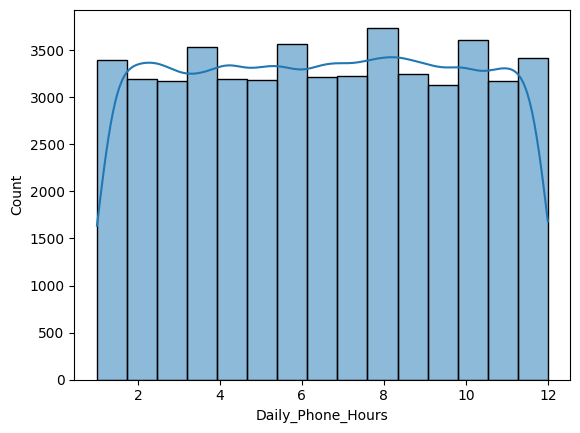

In [47]:
sns.histplot(df['Daily_Phone_Hours'], kde=True, bins=15)

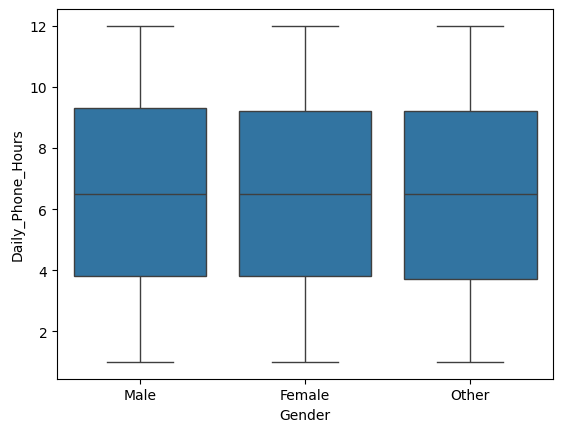

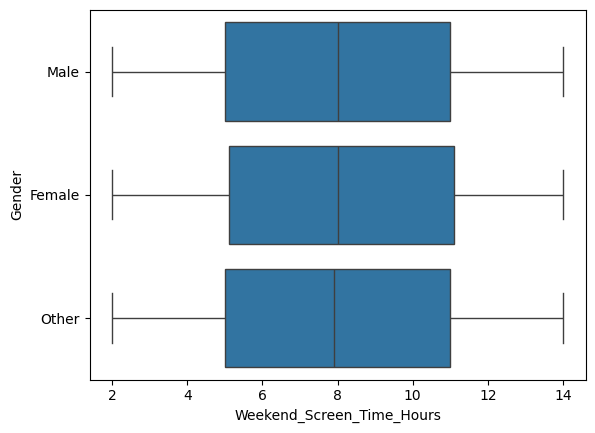

In [48]:
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=df)
plt.show()
# sns.boxplot(x='Gender', y='Age', data=df)
# sns.boxplot(x='Gender', y='Sleep_Hours', data=df)
sns.boxplot(x='Weekend_Screen_Time_Hours', y='Gender', data=df)
plt.show()

In [51]:
#Feature Engineering Create a new COlumn called Age_Group
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 35, 60, np.inf], labels=['Child', 'Young Adult', 'Adult', 'Senior'])
df.groupby('Age_Group')['Daily_Phone_Hours'].mean()

C:\Users\User\AppData\Local\Temp\ipykernel_19268\3814643588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Daily_Phone_Hours'].mean()


Age_Group
Child          6.394831
Young Adult    6.503480
Adult          6.517539
Senior              NaN
Name: Daily_Phone_Hours, dtype: float64